# 02 — Binance Historical OHLCV Loader

Fetches 30 days of 1m OHLCV data for BTC from Binance via CCXT,
then inserts into the DuckDB `ohlcv` table.

## 0. Imports & Config

In [1]:
import duckdb
import pandas as pd
import ccxt
import time
import os
from datetime import datetime, timezone, timedelta
from dotenv import load_dotenv

load_dotenv('../.env')

DB_PATH = os.getenv('DUCKDB_PATH', '../data/research.duckdb')
con = duckdb.connect(DB_PATH)
print(f'Connected to {DB_PATH}')

Connected to ../data/research.duckdb


## 1. Define Target Symbols

Top 5 large-caps from the Roostoo exchange.
Map Roostoo `X/USD` → Binance `X/USDT` → DuckDB `X-USD`.

In [2]:
# Roostoo pair → Binance pair → DuckDB symbol
TARGETS = [
    {'roostoo': 'BTC/USD',  'binance': 'BTC/USDT',  'duckdb': 'BTC-USD'},
    {'roostoo': 'ETH/USD',  'binance': 'ETH/USDT',  'duckdb': 'ETH-USD'},
    {'roostoo': 'SOL/USD',  'binance': 'SOL/USDT',  'duckdb': 'SOL-USD'},
    {'roostoo': 'BNB/USD',  'binance': 'BNB/USDT',  'duckdb': 'BNB-USD'},
    {'roostoo': 'XRP/USD',  'binance': 'XRP/USDT',  'duckdb': 'XRP-USD'},
]

INTERVAL   = '1h'
LOOKBACK   = 180  # days
BATCH_SIZE = 1000  # Binance max per request

since_dt = datetime.now(timezone.utc) - timedelta(days=LOOKBACK)
since_ms = int(since_dt.timestamp() * 1000)

print(f'Lookback from: {since_dt.strftime("%Y-%m-%d %H:%M UTC")}')
print(f'Expected rows per symbol: ~{LOOKBACK * 24}')

Lookback from: 2025-09-19 06:55 UTC
Expected rows per symbol: ~4320


## 2. Fetch OHLCV with Pagination

In [3]:
exchange = ccxt.binance({'enableRateLimit': True})

def fetch_all_ohlcv(exchange, symbol, timeframe, since_ms, batch_size=1000):
    """Paginate through Binance OHLCV data."""
    all_candles = []
    current_since = since_ms
    
    while True:
        candles = exchange.fetch_ohlcv(
            symbol, timeframe=timeframe,
            since=current_since, limit=batch_size
        )
        if not candles:
            break
        all_candles.extend(candles)
        
        # Move past the last candle's timestamp
        current_since = candles[-1][0] + 1
        
        if len(candles) < batch_size:
            break  # No more data
        
        time.sleep(0.1)  # Be polite to the API
    
    return all_candles

print('Fetcher ready.')

Fetcher ready.


In [4]:
for target in TARGETS:
    binance_sym = target['binance']
    db_sym      = target['duckdb']
    
    print(f'\nFetching {binance_sym}...')
    raw = fetch_all_ohlcv(exchange, binance_sym, INTERVAL, since_ms, BATCH_SIZE)
    
    df = pd.DataFrame(raw, columns=['ts_ms', 'open', 'high', 'low', 'close', 'volume'])
    df['ts']       = pd.to_datetime(df['ts_ms'], unit='ms', utc=True)
    df['symbol']   = db_sym
    df['interval'] = INTERVAL
    df['source']   = 'binance'
    df = df[['ts', 'symbol', 'interval', 'open', 'high', 'low', 'close', 'volume', 'source']]
    
    # Drop duplicates (safety for pagination overlap)
    df = df.drop_duplicates(subset=['ts', 'symbol', 'interval'])
    
    con.execute("""
        INSERT OR REPLACE INTO ohlcv
        SELECT ts, symbol, interval, open, high, low, close, volume, source
        FROM df
    """)
    
    print(f'  {db_sym}: {len(df)} rows inserted (range: {df["ts"].min()} → {df["ts"].max()})')

print('\nAll symbols loaded.')


Fetching BTC/USDT...
  BTC-USD: 4320 rows inserted (range: 2025-09-19 07:00:00+00:00 → 2026-03-18 06:00:00+00:00)

Fetching ETH/USDT...
  ETH-USD: 4320 rows inserted (range: 2025-09-19 07:00:00+00:00 → 2026-03-18 06:00:00+00:00)

Fetching SOL/USDT...
  SOL-USD: 4320 rows inserted (range: 2025-09-19 07:00:00+00:00 → 2026-03-18 06:00:00+00:00)

Fetching BNB/USDT...
  BNB-USD: 4320 rows inserted (range: 2025-09-19 07:00:00+00:00 → 2026-03-18 06:00:00+00:00)

Fetching XRP/USDT...
  XRP-USD: 4320 rows inserted (range: 2025-09-19 07:00:00+00:00 → 2026-03-18 06:00:00+00:00)

All symbols loaded.


## 3. Verify

In [5]:
summary = con.execute("""
    SELECT symbol, interval,
           COUNT(*)  AS rows,
           MIN(ts)   AS first_ts,
           MAX(ts)   AS last_ts,
           MIN(close) AS min_price,
           MAX(close) AS max_price
    FROM ohlcv
    GROUP BY symbol, interval
    ORDER BY symbol, interval
""").fetchdf()

print(summary.to_string(index=False))

  symbol interval  rows                  first_ts                   last_ts  min_price   max_price
 BNB-USD       1h  4320 2025-09-19 15:00:00+08:00 2026-03-18 14:00:00+08:00   581.9400   1368.7600
 BTC-USD       1h  4320 2025-09-19 15:00:00+08:00 2026-03-18 14:00:00+08:00 62900.0000 126011.1800
BTC-USDT       1h   200 2026-03-10 07:00:00+08:00 2026-03-18 14:00:00+08:00 68432.1600  75623.9100
 ETH-USD       1h  4320 2025-09-19 15:00:00+08:00 2026-03-18 14:00:00+08:00  1815.7300   4747.4600
 SOL-USD       1h  4320 2025-09-19 15:00:00+08:00 2026-03-18 14:00:00+08:00    75.5100    243.8200
 XRP-USD       1h  4320 2025-09-19 15:00:00+08:00 2026-03-18 14:00:00+08:00     1.1625      3.0902


## 4. Quick Price Chart

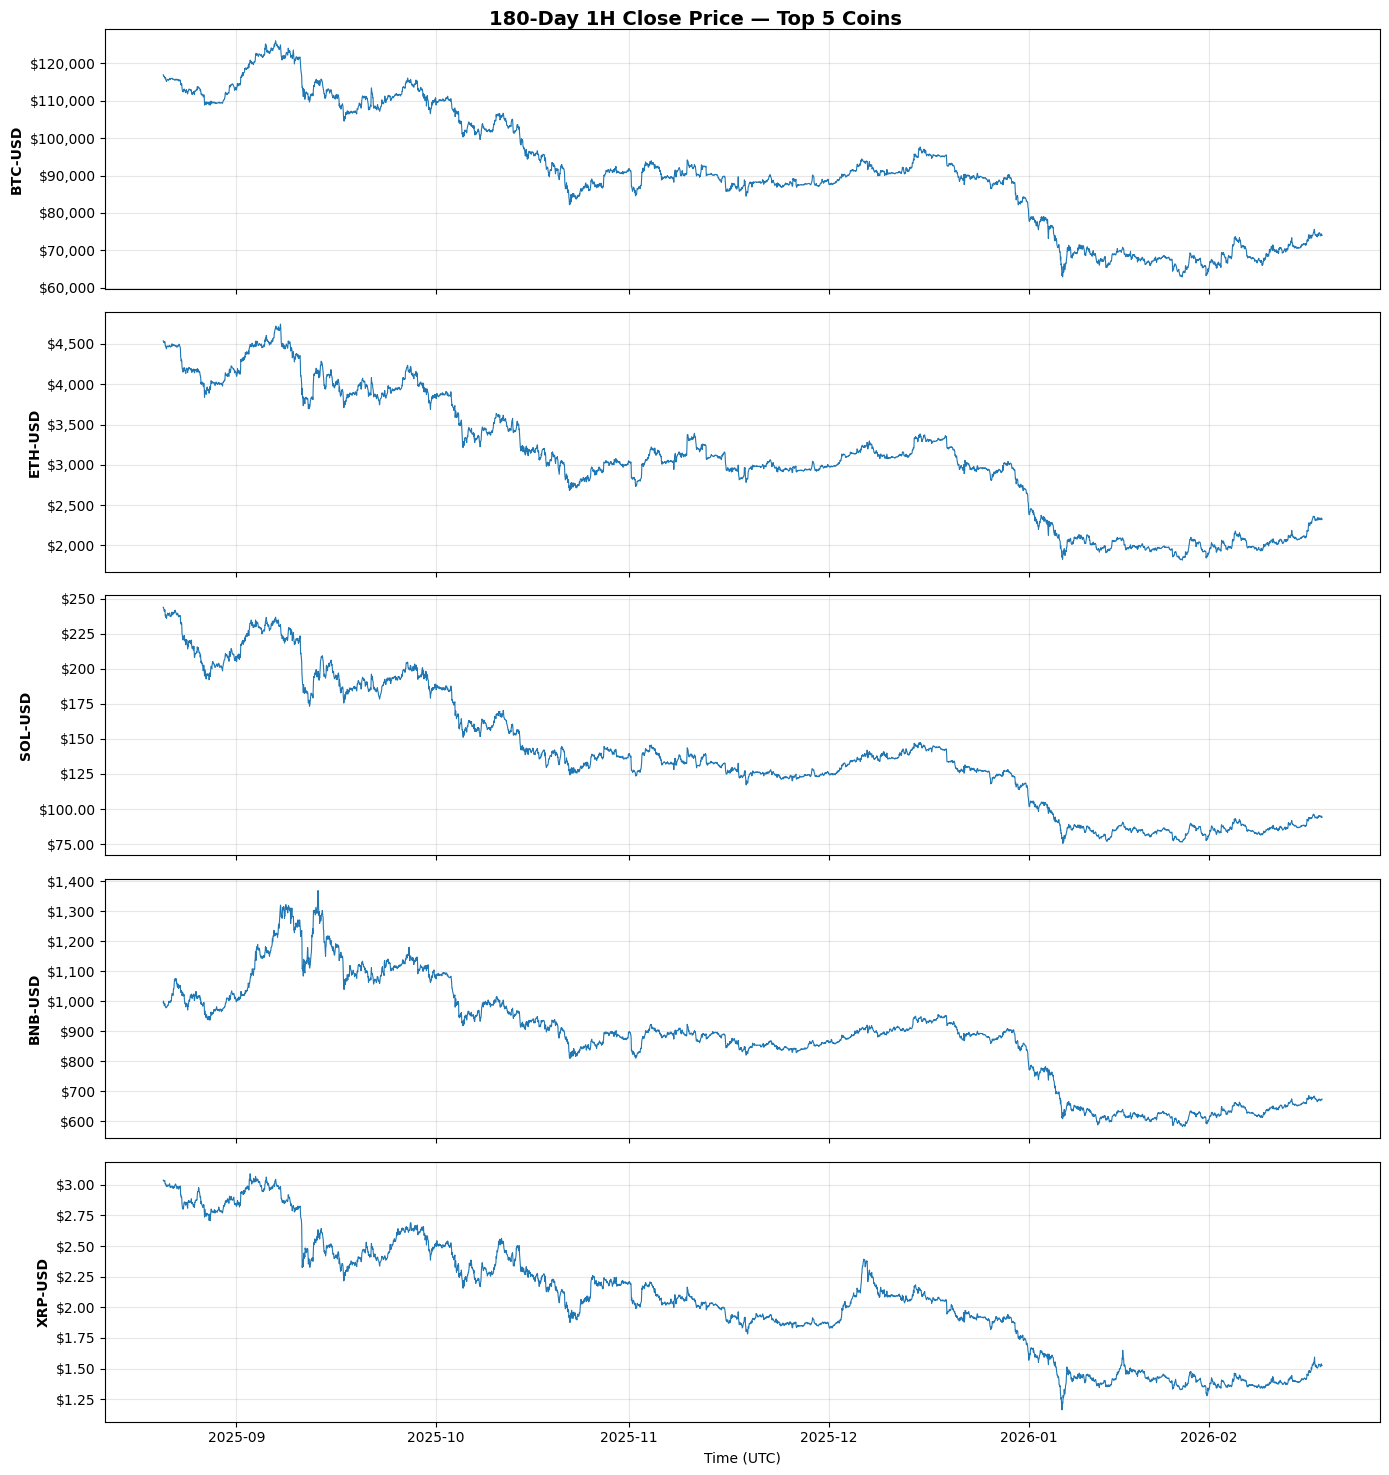

Chart saved to data/top5_price_chart.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

symbols = [t['duckdb'] for t in TARGETS]
fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 3 * len(symbols)), sharex=True)

for ax, sym in zip(axes, symbols):
    pdf = con.execute(f"""
        SELECT ts, close FROM ohlcv
        WHERE symbol = '{sym}' AND interval = '1h'
        ORDER BY ts
    """).fetchdf()
    
    ax.plot(pdf['ts'], pdf['close'], linewidth=0.8)
    ax.set_ylabel(sym, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}' if x > 100 else f'${x:,.2f}'))

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].set_xlabel('Time (UTC)')
fig.suptitle('180-Day 1H Close Price — Top 5 Coins', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/top5_price_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to data/top5_price_chart.png')

## 5. Close

In [7]:
con.close()
print('Done. Next: 03_unravel_signals.ipynb or 04_feature_engineering.ipynb')

Done. Next: 03_unravel_signals.ipynb or 04_feature_engineering.ipynb
